In [61]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd

In [62]:
# source: https://archive.ics.uci.edu/dataset/186/wine+quality
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
wine_quality = fetch_ucirepo(id=186) 
  
# data (as pandas dataframes) 
X = wine_quality.data.features 
y = wine_quality.data.targets 

X

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8


tensor([3, 4, 5, 6, 7, 8, 9])


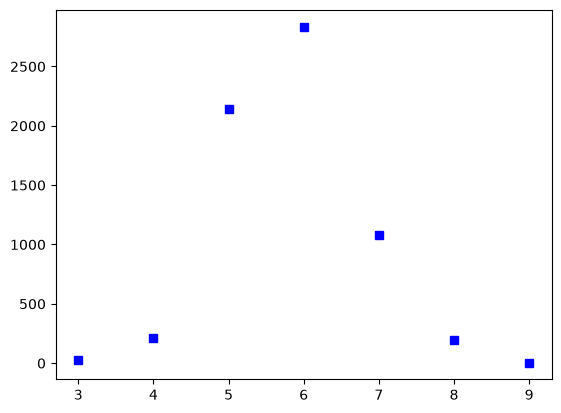

In [63]:
data = torch.tensor(X.values).float()
labels = torch.tensor(y.values, dtype=torch.long)
labels_bin = (labels > 5.0).float()
print(labels.unique())

labels_count = [len(np.where(labels == x)[0]) for x in labels.unique()]
plt.plot(labels.unique(), labels_count, 'bs')
plt.show()

In [64]:
# Experiment 1: train a binary classification model on this dataset
class ModelBinary(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.ModuleDict();

        self.layers['input'] = nn.Linear(11, 16)
        self.layers['hidden1'] = nn.Linear(16, 32)
        self.layers['hidden2'] = nn.Linear(32, 32)
        self.layers['output'] = nn.Linear(32, 1)

    def forward(self, x):
        x = self.layers['input'](x)
        x = F.relu(x)

        x = self.layers['hidden1'](x)
        x = F.relu(x)

        x = self.layers['hidden2'](x)
        x = F.relu(x)

        x = self.layers['output'](x)
        return x
    def fit(self, data, labels, training_epochs, learning_rate, train_size, batch_size):
        loss_func = nn.BCEWithLogitsLoss()
        optimizer = torch.optim.SGD(self.parameters(), lr=learning_rate)

        train_data, test_data, train_labels, test_labels = train_test_split(data, labels, train_size=train_size)
        train_dataset = TensorDataset(train_data, train_labels)
        train_ldr = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

        train_losses = torch.zeros(training_epochs)
        train_accuracy = torch.zeros(training_epochs)
        test_accuracy = torch.zeros(training_epochs)

        for epoch in range(training_epochs):
            self.train()
            batch_losses = torch.zeros(len(train_ldr))
            batch_acc = torch.zeros(len(train_ldr))
            for i, batch in enumerate(train_ldr):
                y_hat = self.forward(batch[0])

                loss = loss_func(y_hat, batch[1])
                batch_losses[i] = loss

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                batch_acc[i] = torch.mean(((y_hat > 0.0).float() == batch[1]).float())
            self.eval()
            train_losses[epoch] = torch.mean(batch_losses)
            train_accuracy[epoch] = torch.mean(batch_acc)
            test_accuracy[epoch] = torch.mean(((self.forward(test_data) > 0.0).float() == test_labels).float())

        return train_losses, train_accuracy, test_accuracy

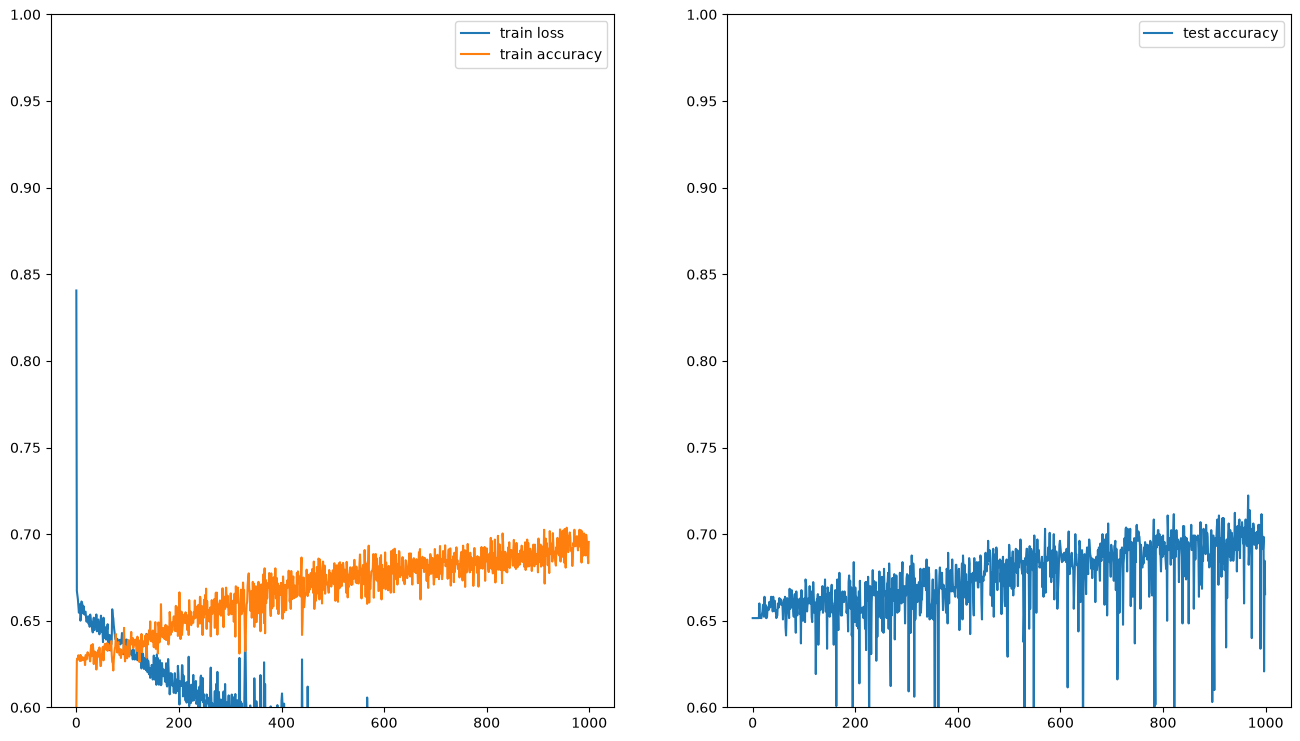

In [65]:
# Experiment 1: train a binary classification model on this dataset
model_reg = ModelBinary()
train_losses_reg, train_accuracy_reg, test_accuracy_reg = model_reg.fit(data, labels_bin, 1000, 0.1, 0.8, 256)

fig, ax = plt.subplots(1, 2, figsize=(16, 9))
ax[0].plot(train_losses_reg.detach(), label='train loss')
ax[0].plot(train_accuracy_reg.detach(), label='train accuracy')
ax[1].plot(test_accuracy_reg.detach(), label='test accuracy')
ax[0].legend()
ax[0].set_ylim(0.6, 1)
ax[1].legend()
ax[1].set_ylim(0.6, 1)
plt.show()

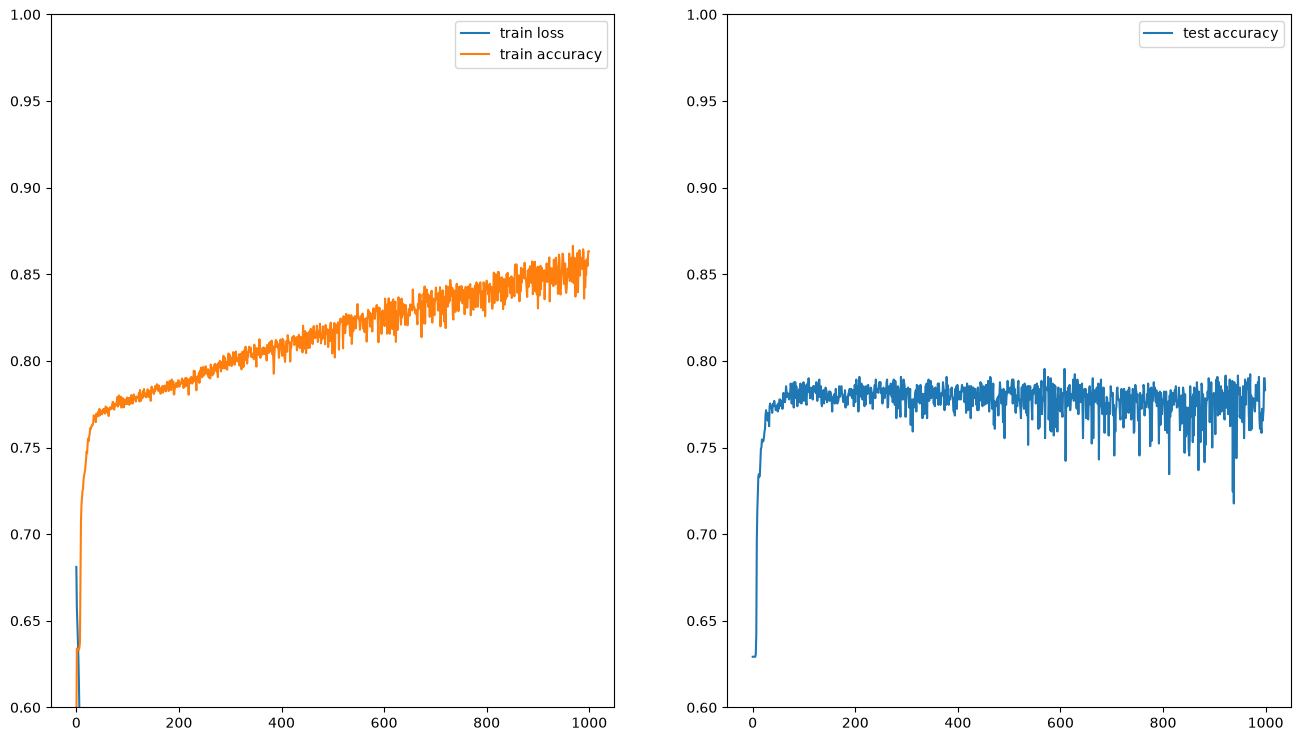

In [66]:
# Experiment 2: normalize data using z-transform
data_norm = (data - torch.mean(data, dim=0, keepdim=True)) / torch.std(data, dim=0, keepdim=True, unbiased=False)

model_data = ModelBinary()
train_losses_data, train_accuracy_data, test_accuracy_data = model_data.fit(data_norm, labels_bin, 1000, 0.1, 0.8, 256)

fig, ax = plt.subplots(1, 2, figsize=(16, 9))
ax[0].plot(train_losses_data.detach(), label='train loss')
ax[0].plot(train_accuracy_data.detach(), label='train accuracy')
ax[1].plot(test_accuracy_data.detach(), label='test accuracy')
ax[0].legend()
ax[0].set_ylim(0.6, 1)
ax[1].legend()
ax[1].set_ylim(0.6, 1)
plt.show()

In [67]:
class ModelBinaryBatchNorm(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.ModuleDict();

        self.layers['input'] = nn.Linear(11, 16)

        self.layers['bnorm1'] = nn.BatchNorm1d(16)
        self.layers['hidden1'] = nn.Linear(16, 32)
        self.layers['bnorm2'] = nn.BatchNorm1d(32)
        self.layers['hidden2'] = nn.Linear(32, 32)

        self.layers['output'] = nn.Linear(32, 1)

    def forward(self, x):
        x = self.layers['input'](x)
        x = F.relu(x)

        x = self.layers['bnorm1'](x)
        x = self.layers['hidden1'](x)
        x = F.relu(x)

        x = self.layers['bnorm2'](x)
        x = self.layers['hidden2'](x)
        x = F.relu(x)

        x = self.layers['output'](x)
        return x
    def fit(self, data, labels, training_epochs, learning_rate, train_size, batch_size):
        loss_func = nn.BCEWithLogitsLoss()
        optimizer = torch.optim.SGD(self.parameters(), lr=learning_rate)

        train_data, test_data, train_labels, test_labels = train_test_split(data, labels, train_size=train_size)
        train_dataset = TensorDataset(train_data, train_labels)
        train_ldr = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

        train_losses = torch.zeros(training_epochs)
        train_accuracy = torch.zeros(training_epochs)
        test_accuracy = torch.zeros(training_epochs)

        for epoch in range(training_epochs):
            self.train()
            batch_losses = torch.zeros(len(train_ldr))
            batch_acc = torch.zeros(len(train_ldr))
            for i, batch in enumerate(train_ldr):
                y_hat = self.forward(batch[0])

                loss = loss_func(y_hat, batch[1])
                batch_losses[i] = loss

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                batch_acc[i] = torch.mean(((y_hat > 0.0).float() == batch[1]).float())
            self.eval()
            train_losses[epoch] = torch.mean(batch_losses)
            train_accuracy[epoch] = torch.mean(batch_acc)
            test_accuracy[epoch] = torch.mean(((self.forward(test_data) > 0.0).float() == test_labels).float())

        return train_losses, train_accuracy, test_accuracy

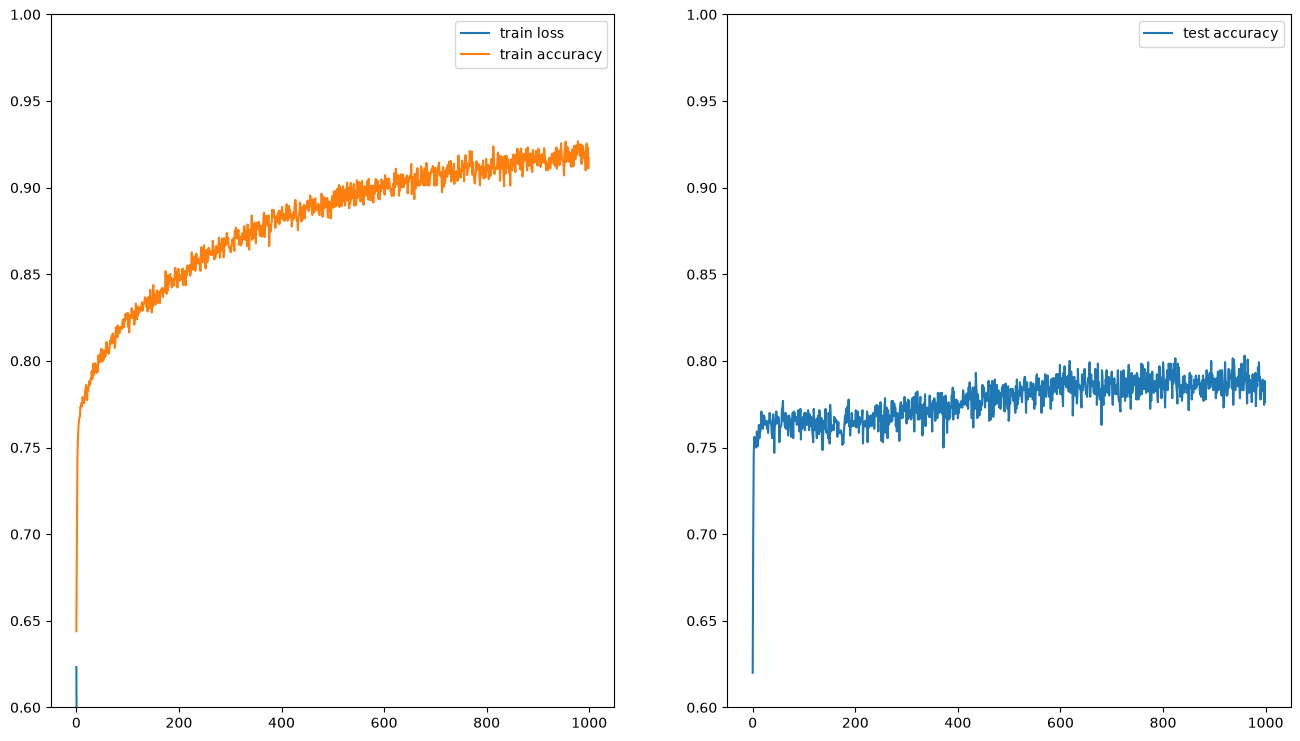

In [73]:
# Experiment 3: data normalization + batch normalization
model_batch = ModelBinaryBatchNorm()
train_losses_batch, train_accuracy_batch, test_accuracy_batch = model_batch.fit(data_norm, labels_bin, 1000, 0.1, 0.8, 256)

fig, ax = plt.subplots(1, 2, figsize=(16, 9))
ax[0].plot(train_losses_batch.detach(), label='train loss')
ax[0].plot(train_accuracy_batch.detach(), label='train accuracy')
ax[1].plot(test_accuracy_batch.detach(), label='test accuracy')
ax[0].legend()
ax[0].set_ylim(0.6, 1)
ax[1].legend()
ax[1].set_ylim(0.6, 1)
plt.show()